# 2620618 - plotting all of our data officially

We want a plot of the simulations, here in jupyter so that we can make a good comparison to Milan's methods. so this is that.

In [56]:
%matplotlib widget 
# from ipywidgets import interact
# import ipywidgets as widgets
# from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.ticker as mticker

# basic functions

This is the essence of the transfer matrix stuff at least in the way that Joe originally composed it. This is something that I want to change at some point but it is fine for now.

In [57]:
#3: Basic functions defined for use
def cos(th):
    return np.cos(th*np.pi/180) 
def costht(ni, nt, ki, kt, thi):
    return(np.sqrt(1-((ni+1j*ki)/(nt+1j*kt)*sin(thi))**2)) 
def arcsin(ratio):
    return np.arcsin(ratio)*180/np.pi 
def sin(th):
    return np.sin(th*np.pi/180) 

mu0 = 4*np.pi*10**-7

#4: Returns transmitted angle from incident angle. It gives you theta t from theta i. 
def snells(ni, nt, ki, kt, thi):
    return(arcsin((ni+1j*ki)/(nt+1j*kt)*sin(thi)))

#5: General form of fresnel coefficients for s polarized light (perpindicular electric field) 
def r_s(ni, nt, ki, kt, thi, mui=4*np.pi*10**-7, mut=4*np.pi*10**-7):
    cos_thi = cos(thi)
    cos_tht = costht(ni, nt, ki, kt, thi)
    return(((ni+1j*ki)/mui*cos_thi-(nt+1j*kt)/mut*cos_tht)/((ni+1j*ki)/mui*cos_thi+(nt+1j*kt)/mut*cos_tht)) 
def t_s(ni, nt, ki, kt, thi, mui=4*np.pi*10**-7, mut=4*np.pi*10**-7):
    cos_thi = cos(thi)
    cos_tht = costht(ni, nt, ki, kt, thi)  
    return((2*(ni+1j*ki)/mui*cos_thi)/((ni+1j*ki)/mui*cos_thi+(nt+1j*kt)/mut*cos_tht))

#6: General form of fresnel coefficients for p polarized light (parrallel electric field)  
def r_p(ni, nt, ki, kt, thi, mui=4*np.pi*10**-7, mut=4*np.pi*10**-7):
    cos_thi = cos(thi)
    cos_tht = costht(ni, nt, ki, kt, thi)
    return((-(nt+1j*kt)/mut*cos_thi+(ni+1j*ki)/mui*cos_tht)/((nt+1j*kt)/mut*cos_thi+(ni+1j*ki)/mui*cos_tht))
def t_p(ni, nt, ki, kt, thi, mui=4*np.pi*10**-7, mut=4*np.pi*10**-7):
    cos_thi = cos(thi)
    cos_tht = costht(ni, nt, ki, kt, thi)
    return((2*(ni+1j*ki)/mui*cos_thi)/((nt+1j*kt)/mut*cos_thi+(ni+1j*ki)/mui*cos_tht))  


#7: transmission matrix for P poloarized light. It relates the electric field on both sides of an interface. 
def D_p(ni, nt, ki, kt, thi, mui=mu0, mut=mu0):
    cos_thi = cos(thi)
    cos_tht = costht(ni, nt, ki, kt, thi)
    return((1/t_p(ni, nt, ki, kt, thi, mui, mut))*(np.array([[1,r_p(ni, nt, ki, kt, thi, mui, mut)],
                                                             [r_p(ni, nt, ki, kt, thi, mui, mut),1]])))  

#8: transmission matrix for S poloarized light. It relates the electric field on both sides of an interface. 
def D_s(ni, nt, ki, kt, thi, mui=mu0, mut=mu0):
    cos_thi = cos(thi)
    cos_tht = costht(ni, nt, ki, kt, thi)
    return((1/t_s(ni, nt, ki, kt, thi, mui, mut))*(np.array([[1,r_s(ni, nt, ki, kt, thi, mui, mut)],
                                                             [r_s(ni, nt, ki, kt, thi, mui, mut),1]])))  


#9: propagation matrix that relates electric field on both ends of the same medium. This is independant of polarazation.
def P(ni, nt, ki, kt, thi, d, wavelength):
    cos_thi = cos(thi)
    cos_tht = costht(ni, nt, ki, kt, thi)
    return(np.array([[np.exp(1j*2*np.pi*d*(nt+1j*kt)*cos_tht/wavelength),0],
                     [0,np.exp(-1j*2*np.pi*d*(nt+1j*kt)*cos_tht/wavelength)]]))


#10: the total fresnell coefficients. Used to relate to total amount of electric field transmitted or reflected in relation to incident electric field. 
# This is currently simulating a two interface system. More can easily be added but updates will need to be made to graphing code and exell file import code. 
def t_s_tot(n0, n1, n2, k0, k1, k2, d, th0, wavelength, mui=mu0, mut=mu0):
    th1 = snells(n0, n1, k0, k1, th0)
    cos_th1 = cos(th1) 
    D_s_1 = D_s(n0, n1, k0, k1, th0, mui, mut) 
    P_s_1 = P(n0, n1, k0, k1, th0, d, wavelength) 
    D_s_2 = D_s(n1, n2, k1, k2, th1, mui, mut) 
    M = D_s_1 @ P_s_1 @ D_s_2 
    M_11 = M[0, 0]
    return(1/M_11)  
def t_p_tot(n0, n1, n2, k0, k1, k2, d, th0, wavelength, mui=mu0, mut=mu0):
    th1 = snells(n0, n1, k0, k1, th0)
    cos_th1 = cos(th1) 
    D_p_1 = D_p(n0, n1, k0, k1, th0, mui, mut) 
    P_p_1 = P(n0, n1, k0, k1, th0, d, wavelength) 
    D_p_2 = D_p(n1, n2, k1, k2, th1, mui, mut) 
    M = D_p_1 @ P_p_1 @ D_p_2 
    M_11 = M[0, 0]
    return(1/M_11)   
def r_s_tot(n0, n1, n2, k0, k1, k2, d, th0, wavelength, mui=mu0, mut=mu0):
    th1 = snells(n0, n1, k0, k1, th0)
    cos_th1 = cos(th1)
    D_s_1 = D_s(n0, n1, k0, k1, th0, mui, mut) 
    P_s_1 = P(n0, n1, k0, k1, th0, d, wavelength) 
    D_s_2 = D_s(n1, n2, k1, k2, th1, mui, mut) 
    M = D_s_1 @ P_s_1 @ D_s_2 
    M_11 = M[0, 0]
    M_21 = M[1, 0]
    return(M_21/M_11) 
def r_p_tot(n0, n1, n2, k0, k1, k2, d, th0, wavelength, mui=mu0, mut=mu0):
    th1 = snells(n0, n1, k0, k1, th0)
    cos_th1 = cos(th1)
    D_p_1 = D_p(n0, n1, k0, k1, th0, mui, mut) 
    P_p_1 = P(n0, n1, k0, k1, th0, d, wavelength) 
    D_p_2 = D_p(n1, n2, k1, k2, th1, mui, mut) 
    M = D_p_1 @ P_p_1 @ D_p_2 
    M_11 = M[0, 0] 
    M_21 = M[1, 0]
    return(M_21/M_11)

def Fresnell_rtot(polarization, i):
    n0, n1, n2 = n0_array[i], n1_array[i], n2_array[i]
    k0, k1, k2 = k0_array[i], k1_array[i], k2_array[i]
    wavelength = 1 / wave_numbers[i] # wave_number is in cm^-1 so this makes wavelength in cm which means that d needs to be in cm
    if polarization == 'p':
        return r_p_tot(n0, n1, n2, k0, k1, k2, d, th0, wavelength)#, t_p_tot(n0, n1, n2, k0, k1, k2, d, th0, wavelength)
    elif polarization=='s':
        return r_s_tot(n0, n1, n2, k0, k1, k2, d, th0, wavelength)#, t_s_tot(n0, n1, n2, k0, k1, k2, d, th0, wavelength)  
    else:
        print('you did not give a correct polarization -- enter s or p')


def reciprocal_cm_um(x):
    x = np.asarray(x, dtype=float)
    out = np.full_like(x, np.nan, dtype=float)
    np.divide(1e4, x, out=out, where=(x != 0))
    return out

need to plot the following method against milan's method for gold to see the difference

In [58]:
import yaml


def set_gold_n2_k2(
    df,
    yml_path="Olmon-ev.yml",
    x_col="wavenumber",
    x_unit="cm^-1",
    n_col="n2",
    k_col="k2",
    clip=True,
):
    """
    add/overwrite gold optical constants in df[n_col] and df[k_col].

    default assumes:
        df["wavenumber"] is in cm^-1
        refractiveindex.info yaml first column is wavelength in micrometers
    """

    with open(yml_path, "r") as f:
        doc = yaml.safe_load(f)

    data_block = None
    for block in doc["DATA"]:
        if "tabulated nk" in block["type"].lower():
            data_block = block["data"]
            break

    if data_block is None:
        raise ValueError("no tabulated nk data found in yaml file")

    au = np.loadtxt(data_block.splitlines())

    table_wavelength_um = au[:, 0]
    table_n = au[:, 1]
    table_kappa = au[:, 2]

    x = df[x_col].to_numpy(dtype=float)

    if x_unit in ["cm^-1", "wavenumber"]:
        table_x = 10000.0 / table_wavelength_um
    elif x_unit in ["um", "micron", "micrometers"]:
        table_x = table_wavelength_um
    elif x_unit == "nm":
        table_x = 1000.0 * table_wavelength_um
    else:
        raise ValueError("x_unit must be 'cm^-1', 'um', or 'nm'")

    # np.interp requires the table x-values to be increasing
    order = np.argsort(table_x)
    table_x = table_x[order]
    table_n = table_n[order]
    table_kappa = table_kappa[order]

    if clip:
        x_interp = np.clip(x, table_x.min(), table_x.max())
    else:
        if x.min() < table_x.min() or x.max() > table_x.max():
            raise ValueError(
                f"df range is {x.min()} to {x.max()}, "
                f"but gold table range is {table_x.min()} to {table_x.max()}"
            )
        x_interp = x

    df[n_col] = np.interp(x_interp, table_x, table_n)
    df[k_col] = np.interp(x_interp, table_x, table_kappa)

    return df

# now for plotting all of the Herguadas data

this has been interpolated from their original data, but that is fine

In [59]:
#1: Here is were you upload your excel file. The path depends on your specific computer. to upload a .csv change to pd.read_csv

df = pd.read_excel("./Herguedas-SiOx-interpolated_2.xlsx", sheet_name='OG Data') # nrows avoids extraneous data at the end of each sheet
df.columns = df.columns.str.replace("p", ".", regex=False)

df['n0'] = 1
df['k0'] = 0
df = set_gold_n2_k2(
    df,
    yml_path="Olmon-ev.yml",
    x_col="wavenumber",
    x_unit="cm^-1",
)

# d is always measured in cm -- 1e-8 cm is 1 angstrom; 10e-8 cm is 1 nanometer
d = 1.65e-8  

# angle is measured in degrees from the normal
th0 = 80 

# setting up other columns that can be helpful
#df['wavelength'] = 1/df['wavenumber']
#df['d'] = d*np.ones(len(df))
#df['th0'] = th0*np.ones(len(df))

In [60]:
df

,wavenumber,wavelength,n0.50,k0.50,n0.55,k0.55,n0.60,k0.60,n0.65,k0.65,...,n1.90,k1.90,n1.95,k1.95,n2.00,k2.00,n0,k0,n2,k2
0,2000.000000,0.000500,2.703576,-0.000041,2.608729,-0.000045,2.517230,-0.000045,2.429079,-0.000042,...,1.313419,0.001065,1.312317,0.001151,1.314563,0.001239,1,0,3.002659,34.306249
1,1998.001998,0.000500,2.703576,-0.000041,2.608729,-0.000045,2.517230,-0.000045,2.429079,-0.000042,...,1.313419,0.001065,1.312317,0.001151,1.314563,0.001239,1,0,3.008585,34.340494
2,1996.007984,0.000501,2.703608,-0.000041,2.608781,-0.000045,2.517299,-0.000045,2.429163,-0.000042,...,1.312994,0.001065,1.311837,0.001151,1.314025,0.001239,1,0,3.014500,34.374669
3,1994.017946,0.000501,2.703427,-0.000041,2.608509,-0.000045,2.516943,-0.000045,2.428727,-0.000042,...,1.312410,0.001065,1.311320,0.001151,1.313582,0.001239,1,0,3.020404,34.408777
4,1992.031873,0.000502,2.703063,-0.000041,2.608137,-0.000045,2.516564,-0.000045,2.428344,-0.000042,...,1.312467,0.001065,1.311417,0.001151,1.313720,0.001239,1,0,3.026295,34.442817
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
796,407.996736,0.002451,2.873967,0.382060,2.814347,0.409236,2.757666,0.434698,2.703924,0.458447,...,2.315433,0.495304,2.338096,0.474503,2.363698,0.451989,1,0,41.963056,135.908023
797,405.992449,0.002463,2.883759,0.372697,2.825373,0.398499,2.769757,0.422627,2.716913,0.445079,...,2.296326,0.461975,2.315524,0.440874,2.337492,0.418098,1,0,42.204187,136.372232
798,404.007757,0.002475,2.891200,0.362399,2.833752,0.386697,2.778931,0.409378,2.726737,0.430443,...,2.275695,0.431646,2.291805,0.410678,2.310543,0.388093,1,0,42.442960,136.831901
799,401.993890,0.002488,2.897205,0.352621,2.840664,0.375381,2.786611,0.396592,2.735046,0.416257,...,2.254595,0.404930,2.267723,0.384359,2.283340,0.362241,1,0,42.685243,137.298329


# first i'm going to plot Milan's interpolated n and k data

the problem with these is that many are not used and others are needed that are not calculated here.

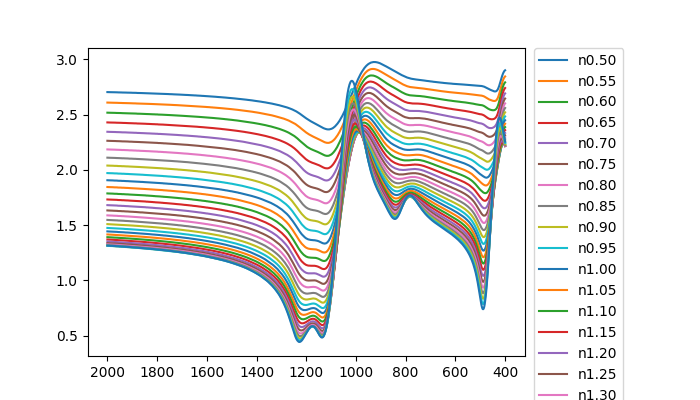

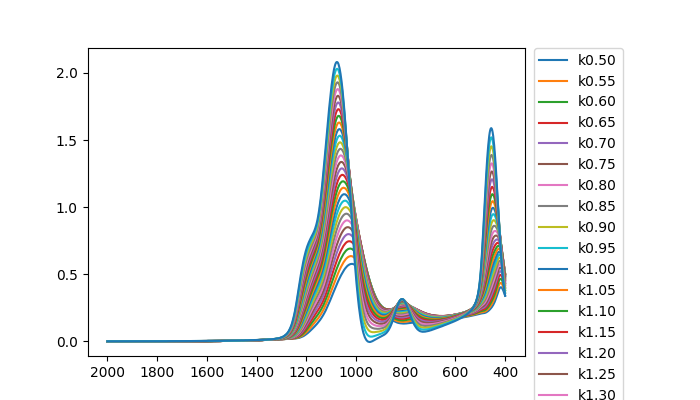

In [61]:
vals = [f"{i:.2f}" for i in np.arange(0.50,2.00+0.05, 0.05)]

ncols = ['n'+v for v in vals]
kcols = ['k'+v for v in vals]

fig_n1, ax_n1 = plt.subplots(figsize=(7, 4))
fig_k1, ax_k1 = plt.subplots(figsize=(7, 4))
ax_n1.plot(df['wavenumber'], df[ncols])
ax_k1.plot(df['wavenumber'], df[kcols])
ax_n1.invert_xaxis()
ax_k1.invert_xaxis()
fig_n1.subplots_adjust(right=0.75)
fig_k1.subplots_adjust(right=0.75)
ax_n1.legend(ncols, bbox_to_anchor=(1.02, 1.0), borderaxespad=0)
ax_k1.legend(kcols, bbox_to_anchor=(1.02, 1.0), borderaxespad=0)

# now for plotting the absorption data based on these values



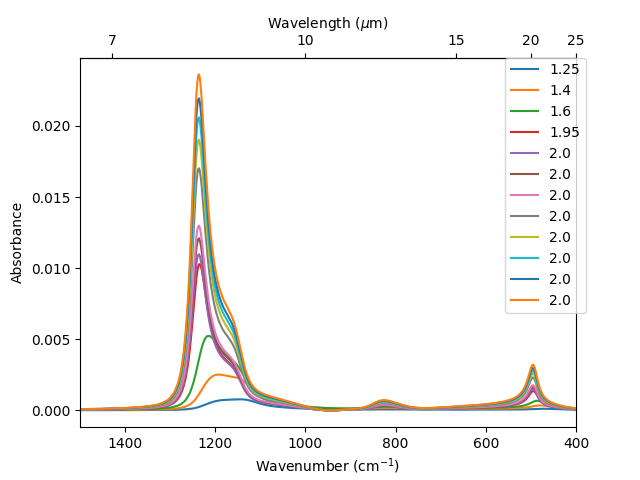

In [65]:
def singleDataRun(df, d, run):
    cols = ['wavenumber', 'wavelength', f'n{run:.2f}', f'k{run:.2f}', 'n0', 'k0', 'n2', 'k2']
    df0 = df.loc[:, cols].copy()
    df0['rtot'] = np.zeros(len(df), dtype=np.complex128)
    
    # optional: rename selected run to generic names used downstream
    df0 = df0.rename(columns={
        f'n{run:.2f}': 'n1',
        f'k{run:.2f}': 'k1',
    })
    
    for i in df0.index:
        df0.at[i, 'rtot'] = r_p_tot(
            df0.at[i, 'n0'], df0.at[i, 'n1'], df0.at[i, 'n2'],
            df0.at[i, 'k0'], df0.at[i, 'k1'], df0.at[i, 'k2'],
            d, th0, df0.at[i, 'wavelength']
        )
    
    df0['R'] = np.abs(df0['rtot'])**2
    
    r_gold = r_p(
        df0["n0"], df0["n2"],
        df0["k0"], df0["k2"],
        th0
    )
    
    df0["R_gold"] = np.abs(r_gold)**2
        
    df0["absorbance"] = np.log10(df0["R"] / df0["R_gold"])
    
    return(df0)

def singlePlot(df):
    fig, ax = plt.subplots()
    ax.set_xlabel(r'Wavenumber (cm$^{-1}$)')
    ax.set_ylabel('Absorbance') 
    ax.invert_xaxis()
    ax.plot(df.wavenumber, df.absorbance)

    
d_values = np.asarray([0.165,  0.37, 0.46, 0.48, 0.49, 0.54, 0.58, 0.76,  0.85, 0.92, 0.98, 1.055])*10**-7
runs =     [1.25, 1.40, 1.60, 1.95, 2.00, 2.00, 2.00,  2.00,  2.00, 2.00, 2.00, 2.00]

fig, ax = plt.subplots() #figsize=(5, 3)) #,constrained_layout=True)
ax.set_xlabel(r'Wavenumber (cm$^{-1}$)')
ax.set_ylabel('Absorbance') 

for i in range(0,12):
    d = d_values[i]
    run = runs[i]
    df0 = singleDataRun(df, d, run)
    #ax.plot(df0.wavenumber, df0.absorbance)
    
    ax.plot(df0.wavenumber, df0.absorbance)

ax.legend(runs)
ax.set_xlim(1500,400)

wave_ticks = [7, 10, 15, 20, 25]   # in microns


sec = ax.secondary_xaxis('top', functions=(reciprocal_cm_um, reciprocal_cm_um))
sec.set_xlabel(r'Wavelength ($\mu$m)')
sec.set_xticks(wave_ticks)
sec.xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:g}'))
    
ax.legend(runs, bbox_to_anchor=(1.02, 1.0), borderaxespad=0)


# milan's data plotted

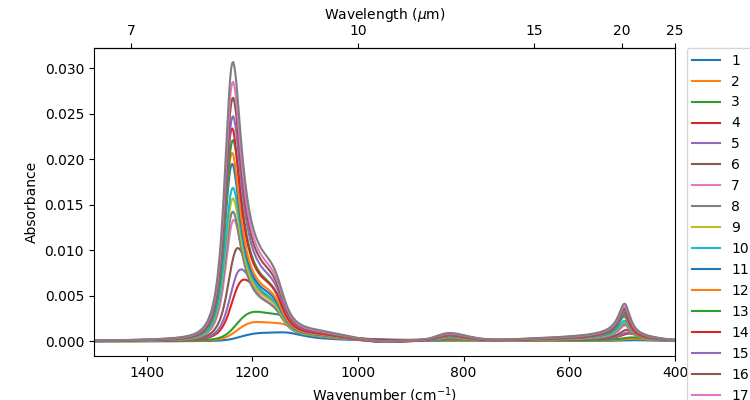

In [63]:
df_milan = pd.read_csv('milanData.csv')
fig1, ax1 = plt.subplots(figsize=(7.5, 4))
ax1.set_xlabel(r'Wavenumber (cm$^{-1}$)')
ax1.set_ylabel('Absorbance') 
ax1.invert_xaxis()
columns = df_milan.columns[1:]
for i in columns:
    ax1.plot(df_milan['wavenumber'], df_milan[i])
ax1.legend(columns, bbox_to_anchor=(1.02, 1.0), borderaxespad=0)
ax1.set_xlim(1500, 400)
sec1 = ax1.secondary_xaxis('top', functions=(reciprocal_cm_um, reciprocal_cm_um))
sec1.set_xlabel(r'Wavelength ($\mu$m)')
sec1.set_xticks(wave_ticks)
sec1.xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:g}'))
fig.tight_layout()